# Modeling

## Анализ сайта "СберАвтоподписка"

Цель ноутбука -> обучить модель машинного обучения, которая предсказывает вероятность совершения пользователем целевого действия на сайте.

На предыдущих этапах были:

- изучены исходные данные
- сформирована целевая переменная `target`
- созданы дополнительные признаки
- подготовлен итоговый датасет для моделирования

На этом этапе будут выполнены:

- загрузка подготовленного датасета
- разделение данных на train/test
- обучение baseline-модели
- обучение основной модели
- оценка качества по ROC-AUC
- построение ROC-кривой
- анализ важности признаков
- сохранение обученного pipeline


## Импорты

In [55]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import json
import pickle

import numpy as np
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных
from sklearn.model_selection import train_test_split

# Pipeline и трансформеры
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Обработка признаков
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Метрики
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## Импорт модулей проекта

In [56]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent
REPOSITORY_DIR = PROJECT_DIR.parents[3]

if str(REPOSITORY_DIR) not in sys.path:
    sys.path.append(str(REPOSITORY_DIR))

from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config import (
    PROCESSED_DATASET_PATH,
    MODEL_PATH,
    METRICS_PATH,
    PREDICTIONS_PATH,
    TARGET_COLUMN,
)

## Загружаем подготовленный датасет

In [57]:
dataset = pd.read_csv(PROCESSED_DATASET_PATH)

print(f"Размер датасета: {dataset.shape}")
dataset.head()

Размер датасета: (1860042, 34)


,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target,visit_month,visit_day,visit_weekday,visit_hour,is_weekend,is_organic_traffic,is_paid_traffic,is_social_traffic,is_first_visit,visit_number_clipped,hit_count,max_hit_number,unique_page_count,unique_event_action_count,unique_event_category_count,has_view_card,has_search,has_pagination,has_quiz,has_subscription_interest
0,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0,11,24,2,14,0,0,1,0,1,1,2.0,4.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
1,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0,11,14,6,8,1,0,1,0,1,1,1.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0,12,28,1,2,0,0,1,0,1,1,16.0,20.0,2.0,3.0,3.0,0.0,1.0,0.0,0.0,1.0
3,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,1,1,3.0,7.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,0,2,2.0,3.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0


In [58]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 34 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   visit_number                 int64  
 1   utm_source                   object 
 2   utm_medium                   object 
 3   utm_campaign                 object 
 4   utm_adcontent                object 
 5   utm_keyword                  object 
 6   device_category              object 
 7   device_os                    object 
 8   device_brand                 object 
 9   device_screen_resolution     object 
 10  device_browser               object 
 11  geo_country                  object 
 12  geo_city                     object 
 13  target                       int64  
 14  visit_month                  int64  
 15  visit_day                    int64  
 16  visit_weekday                int64  
 17  visit_hour                   int64  
 18  is_weekend                   int64  
 19  

In [59]:
dataset[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2)

target
0    96.62
1     3.38
Name: proportion, dtype: float64

Данные имеют выраженный дисбаланс классов, доля визитов с целевым действием составляет около 3.4%.
Поэтому основной метрикой качества будет ROC-AUC, а не accuracy.

## Разделяем признаки и target

In [60]:
X = dataset.drop(columns=[TARGET_COLUMN])
y = dataset[TARGET_COLUMN]

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Размер X: (1860042, 33)
Размер y: (1860042,)


## Определяем числовые и категориальные признаки

In [61]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Количество числовых признаков: {len(numeric_features)}")
print(f"Количество категориальных признаков: {len(categorical_features)}")

Количество числовых признаков: 21
Количество категориальных признаков: 12


In [62]:
numeric_features

['visit_number',
 'visit_month',
 'visit_day',
 'visit_weekday',
 'visit_hour',
 'is_weekend',
 'is_organic_traffic',
 'is_paid_traffic',
 'is_social_traffic',
 'is_first_visit',
 'visit_number_clipped',
 'hit_count',
 'max_hit_number',
 'unique_page_count',
 'unique_event_action_count',
 'unique_event_category_count',
 'has_view_card',
 'has_search',
 'has_pagination',
 'has_quiz',
 'has_subscription_interest']

In [63]:
categorical_features

['utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city']

## Делим данные на train/test

In [64]:
# Для дисбаланса используем stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train target rate: {y_train.mean():.4%}")
print(f"y_test target rate: {y_test.mean():.4%}")

X_train: (1488033, 33)
X_test: (372009, 33)
y_train target rate: 3.3818%
y_test target rate: 3.3816%


## Создаем препроцессинг

In [65]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=100)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Для числовых признаков используется заполнение пропусков медианой и масштабирование.

Для категориальных признаков пропуски заполняются значением `unknown`,
после чего применяется OneHotEncoder.
Для ограничения размерности используется параметр `min_frequency=100`, который объединяет редкие категории.

## Baseline-модель

Baseline нужен для сравнения. Он покажет самый частый класс.

In [66]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline ROC-AUC: {baseline_roc_auc:.4f}")

Baseline accuracy: 0.9662
Baseline ROC-AUC: 0.5000


## Основная модель -> LogisticRegression

In [67]:
logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Оценка LogisticRegression

In [68]:
logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

logreg_accuracy = accuracy_score(y_test, logreg_pred)
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)

print(f"LogisticRegression accuracy: {logreg_accuracy:.4f}")
print(f"LogisticRegression ROC-AUC: {logreg_roc_auc:.4f}")

LogisticRegression accuracy: 0.8697
LogisticRegression ROC-AUC: 0.9266


In [69]:
print(classification_report(y_test, logreg_pred))

              precision    recall  f1-score   support

           0       0.99      0.87      0.93    359429
           1       0.18      0.81      0.30     12580

    accuracy                           0.87    372009
   macro avg       0.59      0.84      0.61    372009
weighted avg       0.97      0.87      0.91    372009



## Матрица ошибок

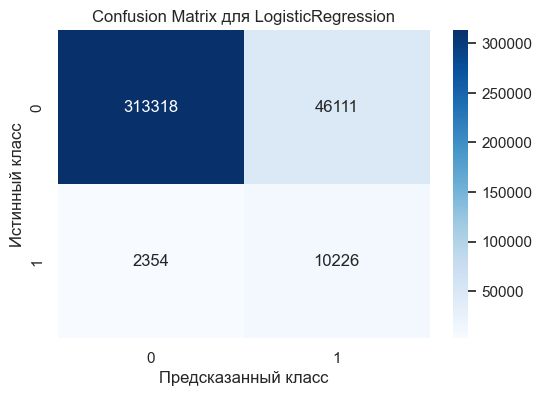

In [70]:
cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("Confusion Matrix для LogisticRegression")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

##  ROC-кривая

ROC-кривая показывает способность модели разделять визиты с целевым действием и без него при разных порогах классификации.
Чем выше ROC-AUC, тем лучше модель ранжирует пользователей по вероятности конверсии.

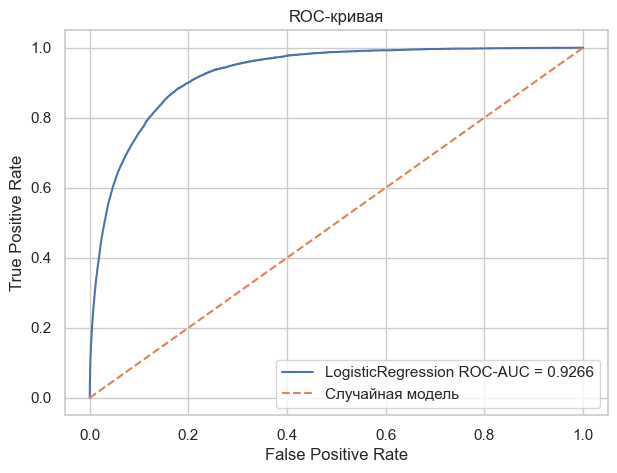

In [71]:
fpr, tpr, thresholds = roc_curve(y_test, logreg_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LogisticRegression ROC-AUC = {logreg_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Случайная модель")
plt.title("ROC-кривая")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Дополнительная модель -> RandomForestClassifier

Ограничим сложность данной модели, чтобы сократить время обучения.

In [72]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [73]:
# Метрики RandomForestClassifier
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"RandomForest accuracy: {rf_accuracy:.4f}")
print(f"RandomForest ROC-AUC: {rf_roc_auc:.4f}")

RandomForest accuracy: 0.7156
RandomForest ROC-AUC: 0.8739


## Сравнение моделей

In [74]:
metrics_df = pd.DataFrame(
    [
        {
            "model": "DummyClassifier",
            "accuracy": baseline_accuracy,
            "roc_auc": baseline_roc_auc,
        },
        {
            "model": "LogisticRegression",
            "accuracy": logreg_accuracy,
            "roc_auc": logreg_roc_auc,
        },
        {
            "model": "RandomForestClassifier",
            "accuracy": rf_accuracy,
            "roc_auc": rf_roc_auc,
        },
    ]
)

metrics_df

,model,accuracy,roc_auc
0,DummyClassifier,0.966184,0.500000
1,LogisticRegression,0.869721,0.926606
2,RandomForestClassifier,0.715598,0.873932


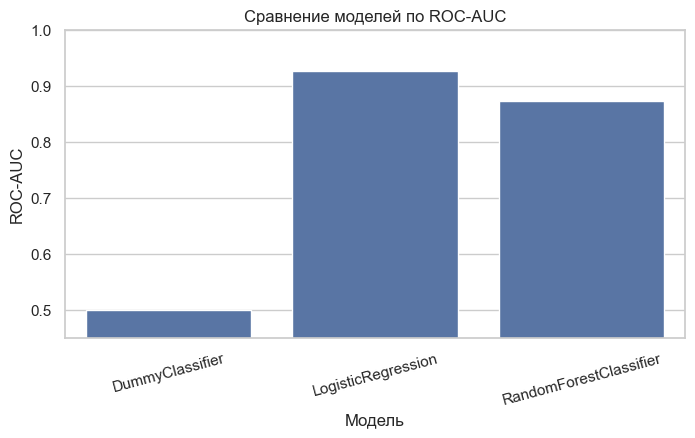

In [75]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=metrics_df,
    x="model",
    y="roc_auc",
)
plt.title("Сравнение моделей по ROC-AUC")
plt.xlabel("Модель")
plt.ylabel("ROC-AUC")
plt.ylim(0.45, 1.0)
plt.xticks(rotation=15)
plt.show()

## Выбор лучшей модели

In [76]:
best_model_name = metrics_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]

if best_model_name == "RandomForestClassifier":
    best_model = rf_model
    best_pred = rf_pred
    best_proba = rf_proba
    best_roc_auc = rf_roc_auc
    best_accuracy = rf_accuracy
else:
    best_model = logreg_model
    best_pred = logreg_pred
    best_proba = logreg_proba
    best_roc_auc = logreg_roc_auc
    best_accuracy = logreg_accuracy

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC лучшей модели: {best_roc_auc:.4f}")

Лучшая модель: LogisticRegression
ROC-AUC лучшей модели: 0.9266


## Интерпретация признаков для LogisticRegression

Коэффициенты логистической регрессии позволяют оценить направление влияния признаков на вероятность целевого действия.

Положительные коэффициенты увеличивают вероятность конверсии, отрицательные соответственно уменьшают.

Примечание:
коэффициенты показывают связь с целевой переменной внутри модели, а не доказывают причинно-следственную зависимость.

In [77]:
feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df.head(30)

,feature,coefficient,abs_coefficient
674,cat__device_screen_resolution_2000x2000,-3.551745,3.551745
15,num__unique_event_category_count,2.921040,2.921040
249,cat__utm_campaign_mIKayglJaKQZvgdtLfqT,-2.422246,2.422246
554,cat__utm_keyword_vOXubAVUYXkYNgrXYqNP,-2.395890,2.395890
291,cat__utm_campaign_yxtFdhyijaALzWWYtzHE,-2.172801,2.172801
59,cat__utm_source_fgymSoTvjKPEgaIJqsiH,-2.060533,2.060533
460,cat__utm_keyword_TzrnweKbRBhjkuRxkdjX,-2.045482,2.045482
246,cat__utm_campaign_kwdmElMUPDZaLQdgjcsI,-1.921300,1.921300
1129,cat__geo_city_Prineville,-1.893408,1.893408
264,cat__utm_campaign_qpUkxmFZPYAfFrViyYab,1.883342,1.883342


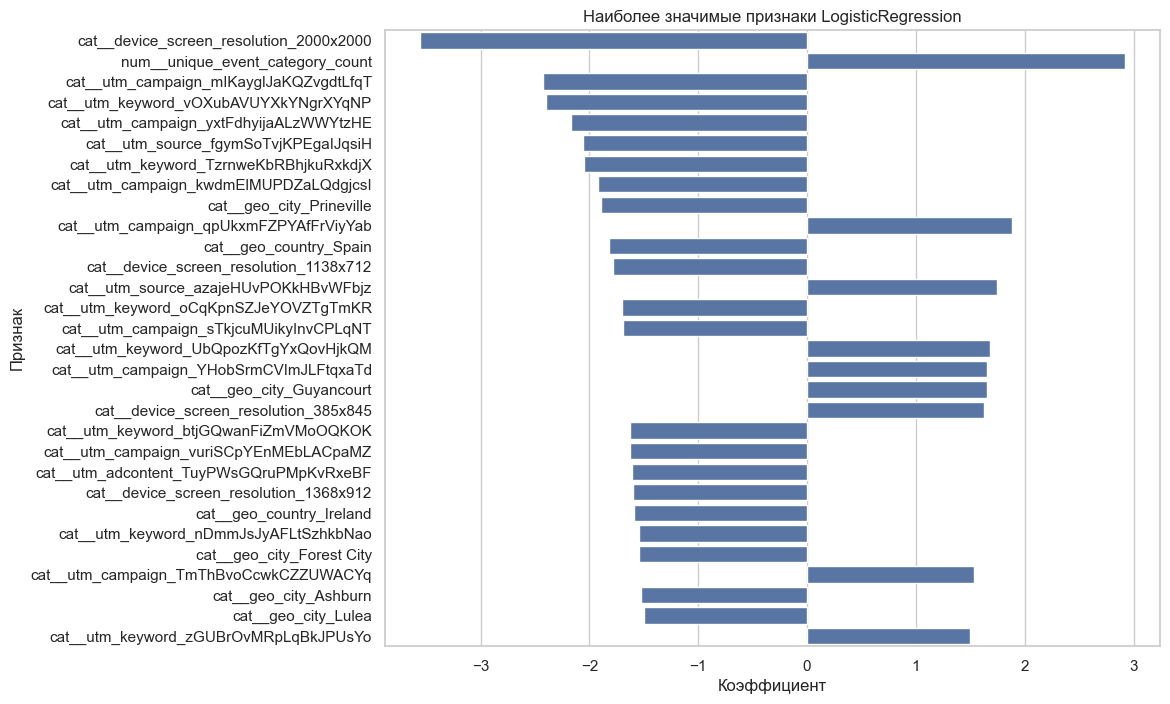

In [78]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_df.head(30),
    x="coefficient",
    y="feature",
)
plt.title("Наиболее значимые признаки LogisticRegression")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.show()

## Вывод по моделированию

На этапе моделирования был использован подготовленный датасет размером `1 860 042` строки и `34` столбца.
Целевая переменная имеет выраженный дисбаланс классов, только около `3.38%` визитов содержат целевое действие,
а около `96.62%` визитов не приводят к конверсии.

Для корректной оценки качества данные были разделены на обучающую и тестовую выборки с сохранением пропорции классов через `stratify=y`.

В качестве baseline-модели был использован `DummyClassifier`, который всегда предсказывает наиболее частый класс.
Он показал высокую accuracy `0.9662`, однако ROC-AUC составил `0.5000`, что соответствует случайному ранжированию.
Это подтверждает, что accuracy не подходит как основная метрика для данной задачи из-за сильного дисбаланса классов.

Основная модель `LogisticRegression` показала лучший результат:

- `accuracy` -> `0.8697`
- `ROC-AUC` -> `0.9266`

Дополнительно была обучена модель `RandomForestClassifier`, которая показала:

- `accuracy` -> `0.7156`
- `ROC-AUC` -> `0.8739`

По основной метрике ROC-AUC лучшей моделью стала `LogisticRegression`.

Примечание:
`accuracy` у LogisticRegression ниже, чем у Baseline.
Это вызвано тем, что Baseline почти всегда предсказывает класс `0` и поэтому получает высокую accuracy за счет дисбаланса.
LogisticRegression при этом лучше выделяет визиты с высокой вероятностью целевого действия, что подтверждается высоким ROC-AUC и recall для класса `1`.

Модель LogisticRegression нашла большую часть конверсионных визитов, recall для класса `1` составил `0.81`.
При этом precision для класса `1` равен `0.18`, что означает наличие ложноположительных срабатываний.
Модель прежде всего полезна для ранжирования визитов по вероятности конверсии и выделения наиболее перспективных пользователей,
поэтому результаты обучения считаем хорошими.

Анализ коэффициентов LogisticRegression показал, что наибольший вклад в предсказание вносят
поведенческие признаки, связанные с количеством уникальных категорий событий, а также отдельные значения UTM-меток, географии и разрешения экрана.
Это означает, что модель использует не только источник трафика и параметры устройства, но и поведение пользователя внутри сессии.

В качестве итоговой модели выбрана `LogisticRegression`,
так как она показала лучший ROC-AUC, быстро обучается на большом объеме данных, возвращает вероятности классов и позволяет интерпретировать вклад признаков.

## Сохраняем предсказания

In [79]:
predictions_df = X_test.copy()
predictions_df["target"] = y_test.values
predictions_df["prediction"] = best_pred
predictions_df["probability"] = best_proba

predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print(f"Предсказания сохранены: {PREDICTIONS_PATH}")
print(f"Размер файла с предсказаниями: {predictions_df.shape}")

Предсказания сохранены: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/outputs/predictions.csv
Размер файла с предсказаниями: (372009, 36)


## Сохраняем метрики

In [80]:
metrics = {
    "baseline": {
        "accuracy": round(float(baseline_accuracy), 4),
        "roc_auc": round(float(baseline_roc_auc), 4),
    },
    "logistic_regression": {
        "accuracy": round(float(logreg_accuracy), 4),
        "roc_auc": round(float(logreg_roc_auc), 4),
    },
    "random_forest": {
        "accuracy": round(float(rf_accuracy), 4),
        "roc_auc": round(float(rf_roc_auc), 4),
    },
    "best_model": {
        "name": best_model_name,
        "accuracy": round(float(best_accuracy), 4),
        "roc_auc": round(float(best_roc_auc), 4),
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, ensure_ascii=False, indent=4)

print(f"Метрики сохранены: {METRICS_PATH}")

Метрики сохранены: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/outputs/metrics.json


## Сохраняем модель

In [81]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(MODEL_PATH, "wb") as file:
    pickle.dump(best_model, file)

print(f"Модель сохранена: {MODEL_PATH}")

Модель сохранена: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/models/model.pkl


## Итог третьего этапа

На этапе моделирования была решена задача бинарной классификации, модель предсказывает вероятность совершения пользователем целевого действия на сайте.

В качестве baseline использовалась модель `DummyClassifier`, которая предсказывает наиболее частый класс
(чтобы показать, что настоящая модель лучше случайного или наивного подхода).

Основная модель была построена с использованием `Pipeline`, который включает:

- обработку числовых признаков
- обработку категориальных признаков
- обучение классификатора

Для оценки качества использовалась метрика ROC-AUC, так как данные имеют выраженный дисбаланс классов.

Лучшая модель была сохранена в файл `models/model.pkl`,
метрики качества в `outputs/metrics.json`,
предсказания на тестовой выборке в `outputs/predictions.csv`.

Полученный результат превышает ориентир по задаче ROC-AUC ~0.65, поэтому модель можно считать успешной.

Полученная модель может использоваться для оценки вероятности конверсии визита и дальнейшего анализа эффективности каналов привлечения трафика.